# LOAD LIBRARIES

In [195]:

import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
from scipy.stats import lognorm 
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet

# CONFIGS

In [196]:
start_date = '2023-11-17'
end_date = '2024-08-23'

Custom plotting function

In [197]:
def plot_data_grid(indat, ncols=3):
    vars = indat.columns
    nrows = (len(vars) + ncols - 1) // ncols  # Calculate the number of rows needed
    relative_markersize = max(1, 10 / len(vars))  # Scale marker size inversely to the number of plots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), constrained_layout=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    for ax, var in zip(axes, vars):
        ax.plot(indat[var], marker='o', markersize=relative_markersize, label=var)
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    # Remove any unused subplots
    for ax in axes[len(vars):]:
        fig.delaxes(ax)
    
    plt.show()

# READ DATA

## FLUXES

Loaded .parquet file ../90_FINAL_MERGE/90.1_FLUXES_METEO_MGMT.parquet (0.665 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,FN2O_L3.3_CUT_50_QCF0,GPP_NT_CUT_50_gfXG_QCF,parcel,parcel_certainty
TIMESTAMP_MIDDLE,,,,
2023-11-17 00:15:00,-0.856583,0.127180,B,certain
2023-11-17 00:45:00,0.475557,0.051548,B,certain
2023-11-17 01:15:00,NaN,-0.167277,B,certain
2023-11-17 01:45:00,0.335770,0.066962,B,certain
2023-11-17 02:15:00,0.420791,0.104486,B,certain
...,...,...,...,...
2024-08-23 21:45:00,NaN,0.407134,B,certain
2024-08-23 22:15:00,1.736854,1.769005,B,certain
2024-08-23 22:45:00,NaN,0.403647,B,certain


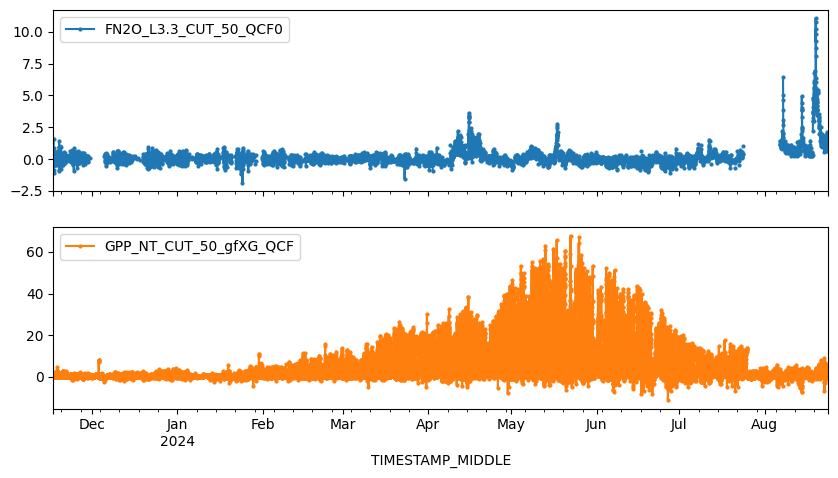

In [198]:
fluxes = load_parquet(filepath=r"../90_FINAL_MERGE/90.1_FLUXES_METEO_MGMT.parquet")
# select relevant columns
cols = ['FN2O_L3.3_CUT_50_QCF0', 'GPP_NT_CUT_50_gfXG_QCF', 'parcel', 'parcel_certainty']
fluxes = fluxes[start_date:end_date][cols].copy()

# plots
indat = fluxes.drop(columns=['parcel', 'parcel_certainty'])
indat.plot(kind='line', subplots=True, layout=(3,1), figsize=(10,8), marker='o', markersize=2);

# show data
fluxes

## METEO

Bulk density data used for WFPS calculation was measured on May 2025.
See file CH-TAN_20250520_soil_bulk_density.xlsx

Loaded .parquet file ../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.145 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


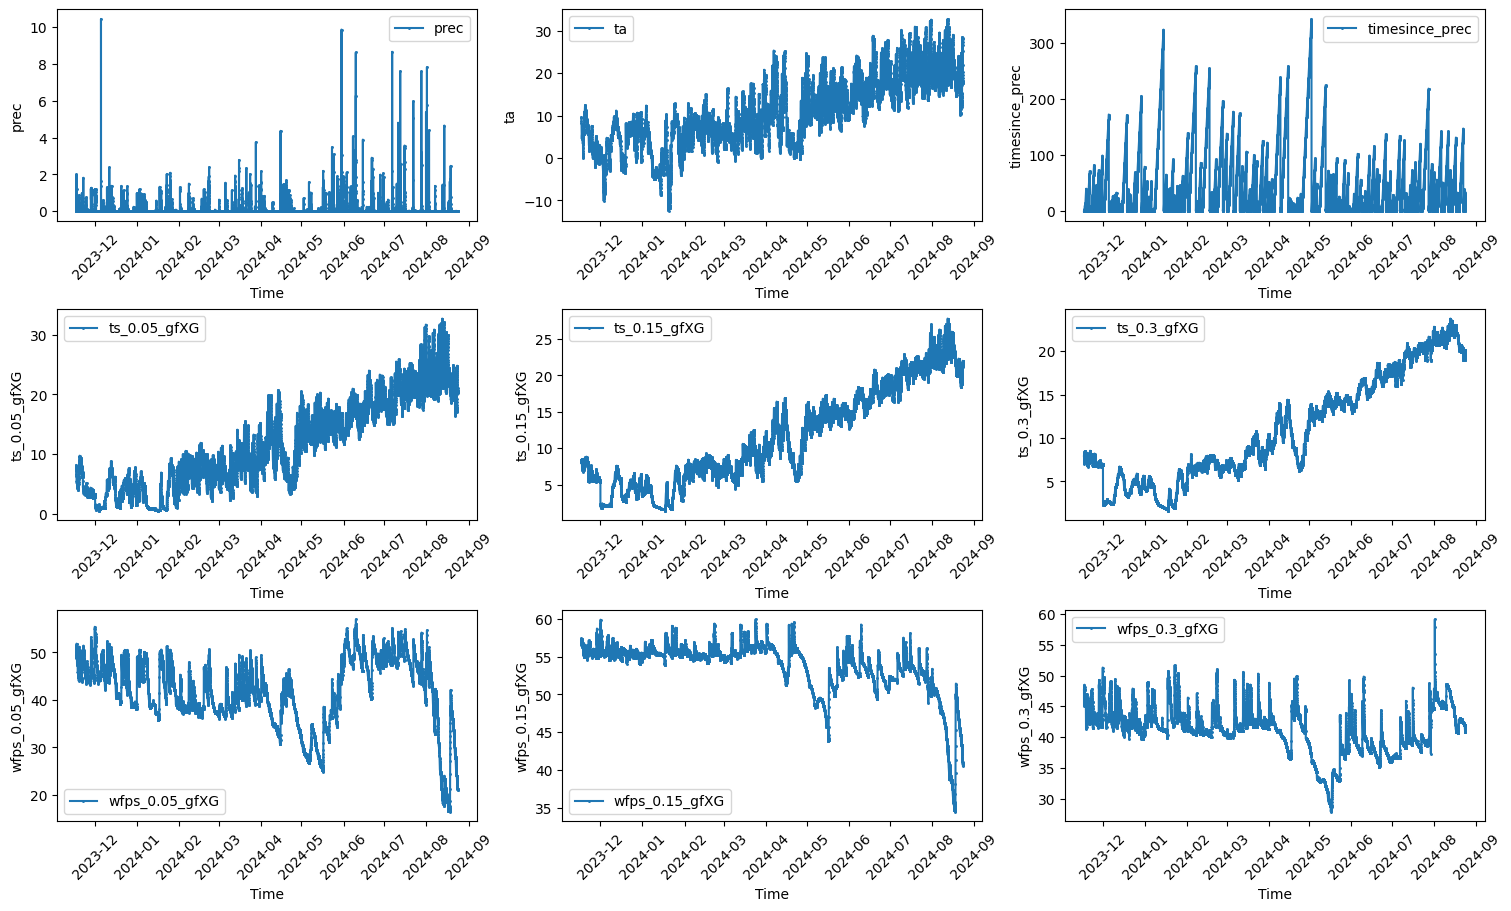

,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG
TIMESTAMP_MIDDLE,,,,,,,,,
2023-11-17 00:15:00,0.4,9.566667,0,7.709492,8.325279,7.916219,49.502770,56.892382,47.683352
2023-11-17 00:45:00,0.0,9.366667,1,7.761147,8.289317,8.027843,49.551355,56.627501,47.442247
2023-11-17 01:15:00,1.3,8.766667,0,7.761220,8.320014,7.992190,50.301234,56.998115,45.149837
2023-11-17 01:45:00,0.0,8.266667,1,7.857418,8.122566,7.730629,51.047444,57.447161,47.225054
2023-11-17 02:15:00,0.0,7.933333,2,8.173503,7.878799,7.674198,50.663760,57.024333,46.870352
...,...,...,...,...,...,...,...,...,...
2024-08-23 21:45:00,0.0,18.230000,29,21.014073,21.597037,20.125925,21.228963,40.716937,40.936844
2024-08-23 22:15:00,0.0,18.056667,30,20.765184,21.467037,20.129259,21.180444,40.674886,40.953472
2024-08-23 22:45:00,0.0,17.716667,31,20.557037,21.365185,20.128518,21.149915,40.648349,40.979679


In [199]:
meteo = load_parquet(filepath=r"../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
meteo = meteo[start_date:end_date].copy()

cols =['prec',
       'ta',
       'timesince_prec', 
       'ts_0.05_gfXG',
       'ts_0.15_gfXG', 
       'ts_0.3_gfXG',
       'swc_0.05_gfXG',
       'swc_0.15_gfXG',
       'swc_0.3_gfXG'
       ]

meteo = meteo[cols]

# Calculate WFPS from SWC using formula with bulk density and particle density
bulk_density = {
    '0.05': 1.1, 
    '0.15': 1.1, 
    '0.3': 1.2, 
}

# Standard particle density since it was not measured
particle_density = 2.65

# Iterate over SWC columns and compute WFPS
swc_cols = [col for col in meteo if col.startswith('swc_')]
for col in swc_cols:
    new_name = col.replace('swc', 'wfps')
    for depth, bd in bulk_density.items():
        if depth in col:
            # calculate wfps for current depth
            wfps = meteo[col] / (1 - (bd / particle_density)) # no need to multiply by 100 because swc is in percent
            meteo[new_name] = wfps
            break

# Now we can remove all the swc columns from which we calculated wfps
meteo.drop(columns=swc_cols, inplace=True)

# plots
plot_data_grid(meteo, ncols=3)

# show data
meteo

## MANAGEMENT

Loaded .parquet file ../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet (0.087 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


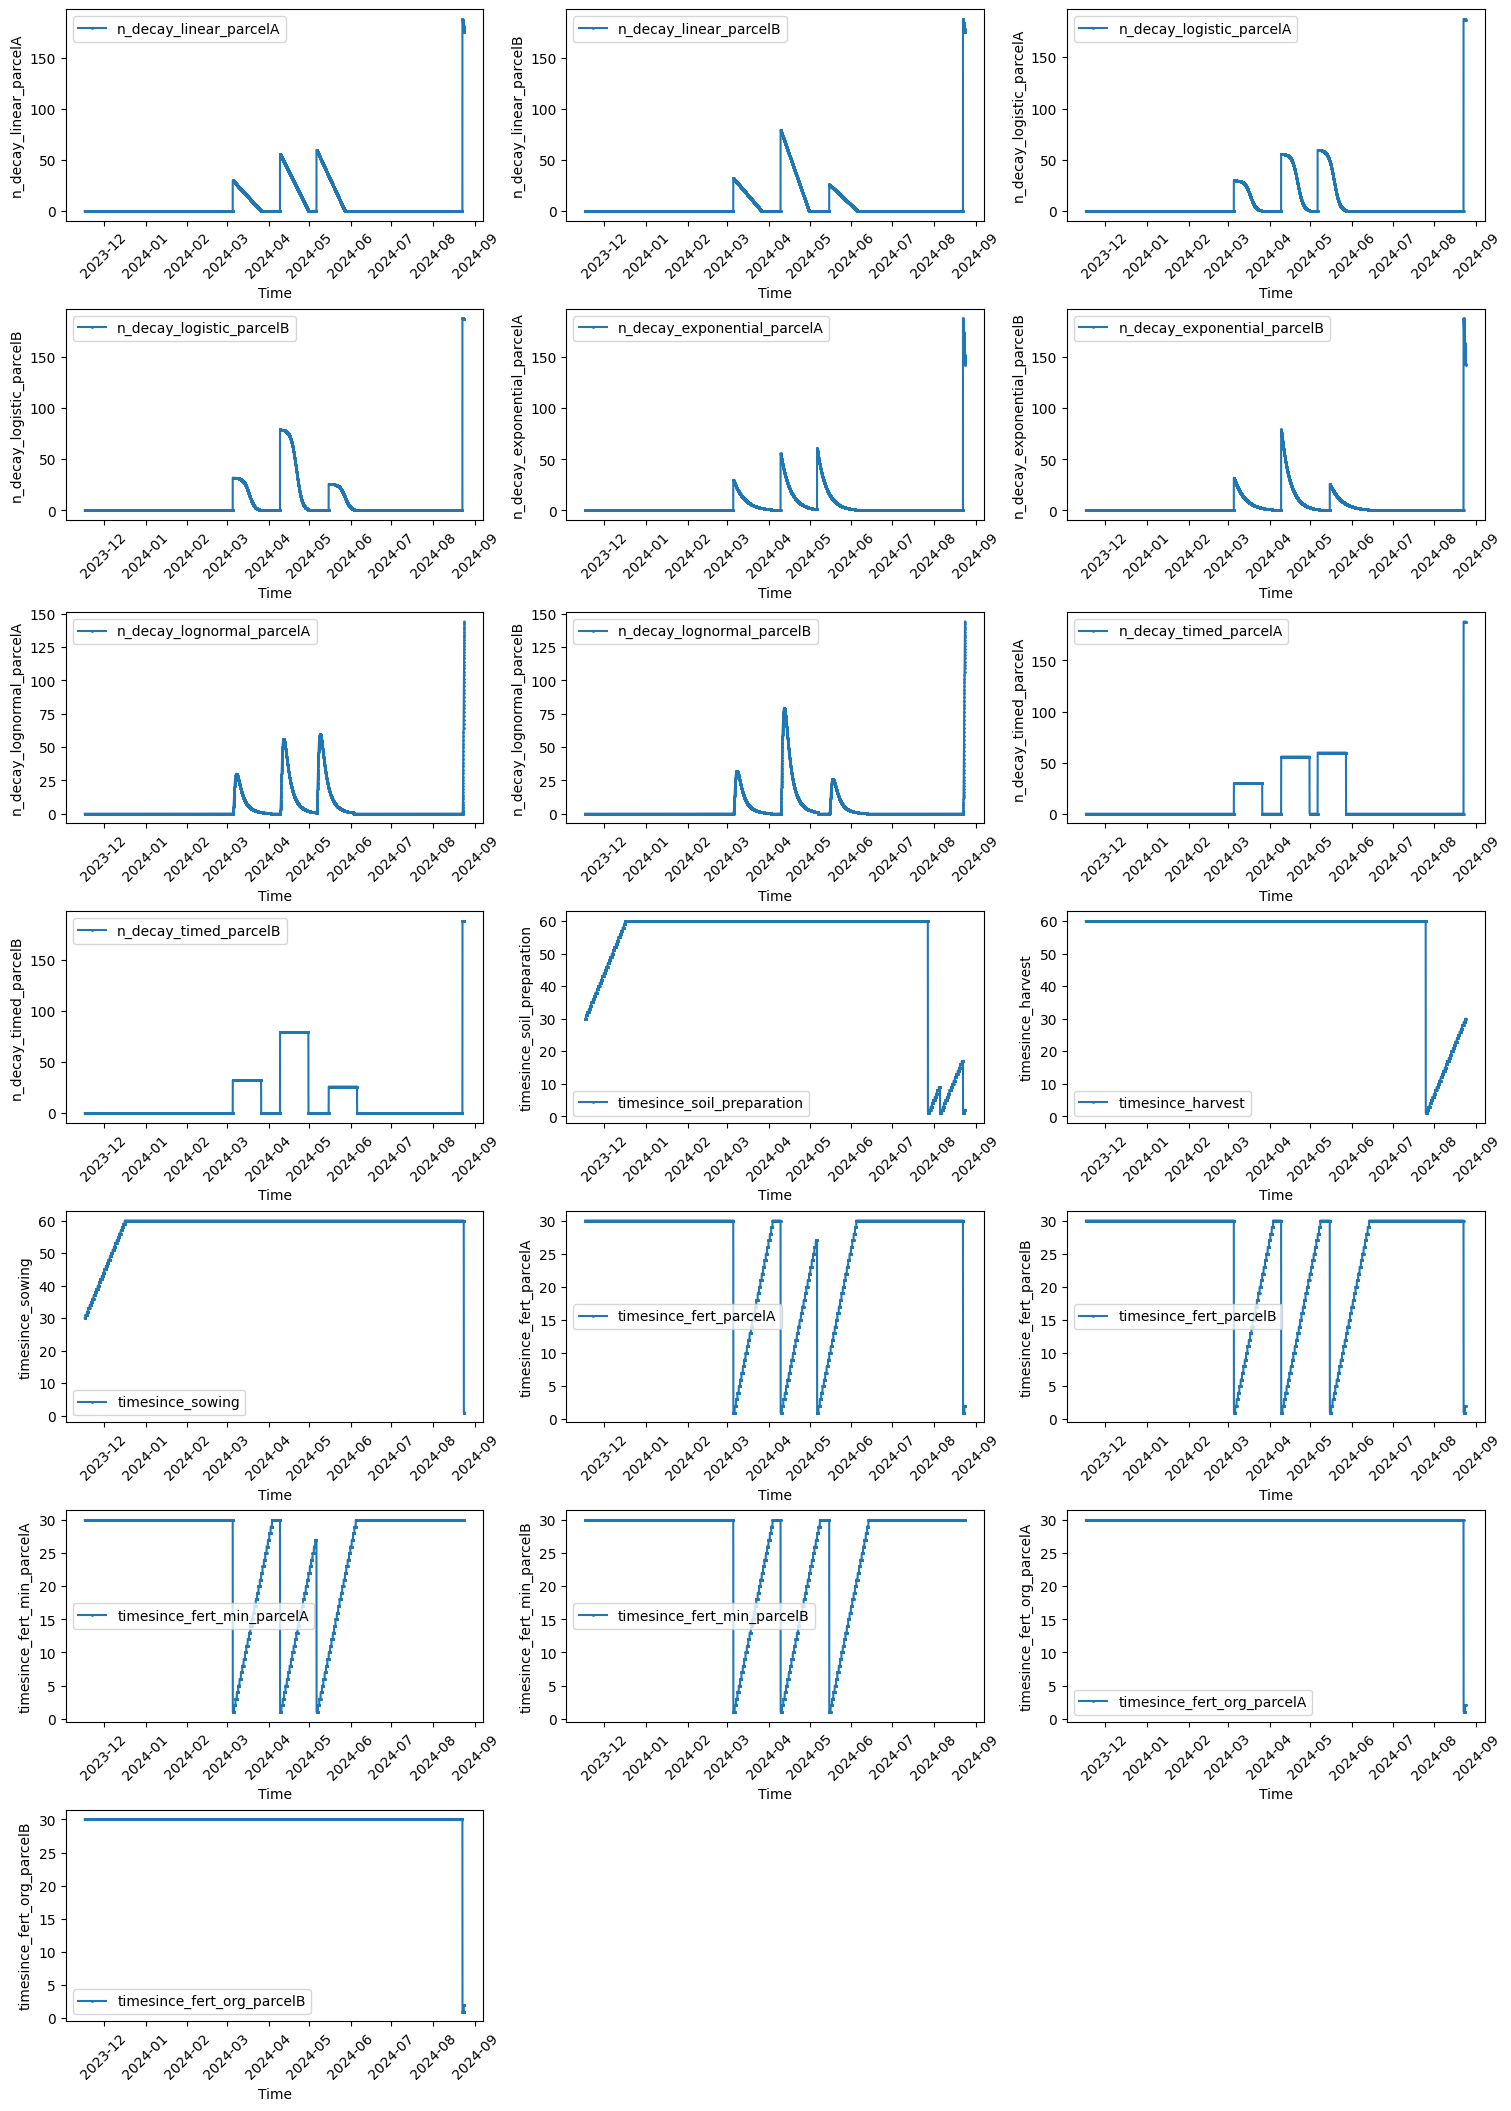

,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,timesince_fert_min_parcelA,timesince_fert_min_parcelB,timesince_fert_org_parcelA,timesince_fert_org_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,
2023-11-17 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 01:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 02:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 21:45:00,175.503968,175.503968,186.849378,186.849378,144.806606,144.806606,136.448807,136.448807,188.0,188.0,2,30,1,2,2,30,30,2,2
2024-08-23 22:15:00,175.317460,175.317460,186.837885,186.837885,144.243513,144.243513,138.433911,138.433911,188.0,188.0,2,30,1,2,2,30,30,2,2
2024-08-23 22:45:00,175.130952,175.130952,186.826279,186.826279,143.682610,143.682610,140.372959,140.372959,188.0,188.0,2,30,1,2,2,30,30,2,2


In [200]:
management = load_parquet(filepath=r"../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet")
management = management[start_date:end_date].copy()

# select subset of columns
prefix = ('n_decay', 'timesince', 'timed')
cols = [c for c in management.columns if c.startswith(prefix)]
management = management[cols]

# plots
plot_data_grid(management, ncols=3)

# show data
management

## CANOPY

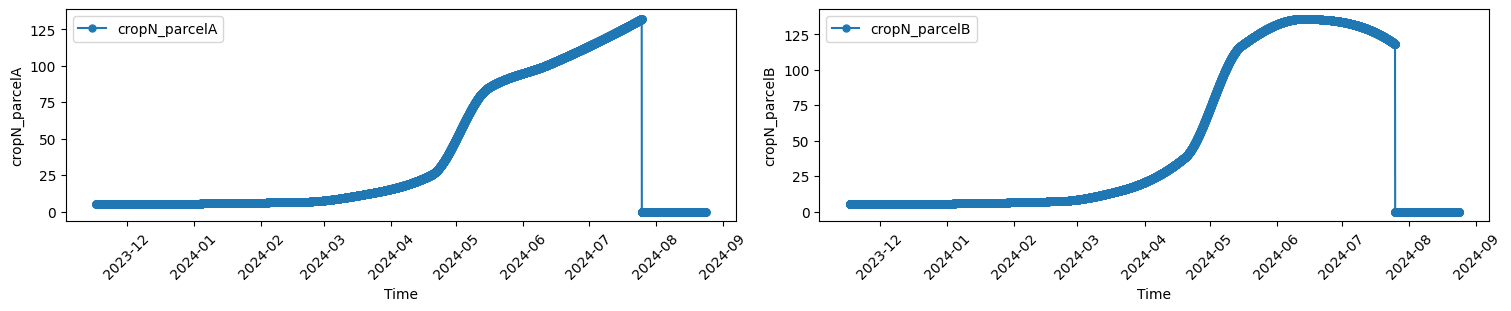

,cropN_parcelA,cropN_parcelB
TIMESTAMP_MIDDLE,,
2023-11-17 00:15:00,5.027077,5.035299
2023-11-17 00:45:00,5.027151,5.035396
2023-11-17 01:15:00,5.027226,5.035493
2023-11-17 01:45:00,5.027300,5.035590
2023-11-17 02:15:00,5.027375,5.035688
...,...,...
2024-08-23 21:45:00,0.002648,0.001622
2024-08-23 22:15:00,0.002933,0.001797
2024-08-23 22:45:00,0.003234,0.001981


In [201]:
vars_ = ["cropN"]
canopy = None
for var in vars_:
    df = pd.read_csv(f"../../data/CANOPY/02-{var}_model.csv")
    canopy = df if canopy is None else canopy.merge(df, on='TIMESTAMP_MIDDLE', how="outer")

canopy = canopy.sort_values('TIMESTAMP_MIDDLE')
canopy['TIMESTAMP_MIDDLE'] = pd.to_datetime(canopy['TIMESTAMP_MIDDLE'])
canopy.set_index('TIMESTAMP_MIDDLE', inplace=True)
canopy = canopy[start_date:end_date].copy()
# select only parcel columns
canopy = canopy[[c for c in canopy if 'parcel' in c]].copy()

# plots
plot_data_grid(canopy, ncols=2)

# show data
canopy

# MERGE DATA

## MERGE

In [202]:
df = pd.concat([fluxes, meteo, management, canopy], axis=1)

## SANITIZE TIMESTAMP

In [203]:
# Remove duplicates, keep first
locs_duplicates = df.index.duplicated(keep='first')
print(f"Found duplicates in index: {locs_duplicates.sum()}")
df = df[~locs_duplicates]

# Remove NaTs
locs_nats = df.index.isnull()
print(f"Found NaTs in index: {locs_nats.sum()}")
df = df[~locs_nats]

# Sort timestamp index
df = df.sort_index(ascending=True)

df

Found duplicates in index: 0
Found NaTs in index: 0


,FN2O_L3.3_CUT_50_QCF0,GPP_NT_CUT_50_gfXG_QCF,parcel,parcel_certainty,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,n_decay_linear_parcelA,n_decay_linear_parcelB,...,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,timesince_fert_min_parcelA,timesince_fert_min_parcelB,timesince_fert_org_parcelA,timesince_fert_org_parcelB,cropN_parcelA,cropN_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:15:00,-0.856583,0.127180,B,certain,0.4,9.566667,0,7.709492,8.325279,7.916219,49.502770,56.892382,47.683352,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027077,5.035299
2023-11-17 00:45:00,0.475557,0.051548,B,certain,0.0,9.366667,1,7.761147,8.289317,8.027843,49.551355,56.627501,47.442247,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027151,5.035396
2023-11-17 01:15:00,NaN,-0.167277,B,certain,1.3,8.766667,0,7.761220,8.320014,7.992190,50.301234,56.998115,45.149837,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027226,5.035493
2023-11-17 01:45:00,0.335770,0.066962,B,certain,0.0,8.266667,1,7.857418,8.122566,7.730629,51.047444,57.447161,47.225054,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027300,5.035590
2023-11-17 02:15:00,0.420791,0.104486,B,certain,0.0,7.933333,2,8.173503,7.878799,7.674198,50.663760,57.024333,46.870352,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027375,5.035688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 21:45:00,NaN,0.407134,B,certain,0.0,18.230000,29,21.014073,21.597037,20.125925,21.228963,40.716937,40.936844,175.503968,175.503968,...,136.448807,136.448807,188.0,188.0,2,30,1,2,2,30,30,2,2,0.002648,0.001622
2024-08-23 22:15:00,1.736854,1.769005,B,certain,0.0,18.056667,30,20.765184,21.467037,20.129259,21.180444,40.674886,40.953472,175.317460,175.317460,...,138.433911,138.433911,188.0,188.0,2,30,1,2,2,30,30,2,2,0.002933,0.001797
2024-08-23 22:45:00,NaN,0.403647,B,certain,0.0,17.716667,31,20.557037,21.365185,20.128518,21.149915,40.648349,40.979679,175.130952,175.130952,...,140.372959,140.372959,188.0,188.0,2,30,1,2,2,30,30,2,2,0.003234,0.001981


In [204]:
[c for c in df.columns if 'parcel' in c]

['parcel',
 'parcel_certainty',
 'n_decay_linear_parcelA',
 'n_decay_linear_parcelB',
 'n_decay_logistic_parcelA',
 'n_decay_logistic_parcelB',
 'n_decay_exponential_parcelA',
 'n_decay_exponential_parcelB',
 'n_decay_lognormal_parcelA',
 'n_decay_lognormal_parcelB',
 'n_decay_timed_parcelA',
 'n_decay_timed_parcelB',
 'timesince_fert_parcelA',
 'timesince_fert_parcelB',
 'timesince_fert_min_parcelA',
 'timesince_fert_min_parcelB',
 'timesince_fert_org_parcelA',
 'timesince_fert_org_parcelB',
 'cropN_parcelA',
 'cropN_parcelB']

# RESAMPLE

In [205]:
frequency = "24h"  # or "8h"
flux_col = "FN2O_L3.3_CUT_50_QCF0"

metadata_cols = ["parcel", "parcel_certainty"]

# If you truly have parcel-specific columns like "..._parcelA" / "..._parcelB"
parcel_cols_A = [c for c in df.columns if "_parcelA" in c]
parcel_cols_B = [c for c in df.columns if "_parcelB" in c]
parcel_specific_cols = parcel_cols_A + parcel_cols_B

# Shared drivers: aggregate from FULL dataset (do not filter by parcel)
shared_cols = [
    c for c in df.columns
    if c not in metadata_cols + parcel_specific_cols + [flux_col]
]
agg_map_shared = {c: ("sum" if c.startswith("prec") or c.startswith("GPP") else "max" if c.startswith('timesince') else "mean") for c in shared_cols}
shared_resampled = df[shared_cols].resample(frequency).agg(agg_map_shared)

# Flux: aggregate PER PARCEL using only confident assignments
mask_A = (df["parcel"] == "A") & (df["parcel_certainty"] == "certain")
mask_B = (df["parcel"] == "B") & (df["parcel_certainty"] == "certain")
flux_A = df.loc[mask_A, flux_col].resample(frequency).mean().rename(flux_col)
flux_B = df.loc[mask_B, flux_col].resample(frequency).mean().rename(flux_col)

# Parcel-specific drivers
agg_map_A = {c: ("max" if c.startswith("timesince") else "mean") for c in parcel_cols_A}
agg_map_B = {c: ("max" if c.startswith("timesince") else "mean") for c in parcel_cols_B}

parcelA_specific_resampled = (
    df[parcel_cols_A].resample(frequency).agg(agg_map_A) if parcel_cols_A else pd.DataFrame(index=shared_resampled.index)
)
parcelB_specific_resampled = (
    df[parcel_cols_B].resample(frequency).agg(agg_map_B) if parcel_cols_B else pd.DataFrame(index=shared_resampled.index)
)

# Build two separate dataframes for each parcel
# A
df_A = pd.concat([shared_resampled, parcelA_specific_resampled, flux_A.rename(flux_col)], axis=1)
df_A["trt"] = 0
# B
df_B = pd.concat([shared_resampled, parcelB_specific_resampled, flux_B.rename(flux_col)], axis=1)
df_B["trt"] = 1

# Get rid of the suffix for parcel from column names
df_A.columns = df_A.columns.str.replace('_parcelA$', '', regex=True)
df_B.columns = df_B.columns.str.replace('_parcelB$', '', regex=True)

# Check the aggregated datasets
print("Shared rows:", shared_resampled.shape[0])
print("\nParcel A dataframe:\n rows:", df_A.shape[0], "\nnon-NA flux:", df_A[flux_col].notna().sum())
print("\nParcel B dataframe:\n rows:", df_B.shape[0], "\nnon-NA flux:", df_B[flux_col].notna().sum())

# Show the dataframes
display(df_A)
display(df_B)

Shared rows: 281

Parcel A dataframe:
 rows: 281 
non-NA flux: 170

Parcel B dataframe:
 rows: 281 
non-NA flux: 232


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,cropN,FN2O_L3.3_CUT_50_QCF0,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.028860,0.197910,0
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.032662,0.095548,0
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.036708,NaN,0
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.041002,0.059226,0
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.045545,0.194346,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,0.000000,5.894838,0
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,0.000000,3.939874,0
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,0.000000,NaN,0


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,cropN,FN2O_L3.3_CUT_50_QCF0,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.037627,0.005580,1
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.042591,0.353820,1
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.047878,0.065356,1
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.053488,-0.024559,1
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.059424,0.060150,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,0.000000,5.095387,1
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,0.000000,2.381710,1
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,0.000000,1.615493,1


# LAGGED VARIANTS

Variables for which lagged variants will be calculated:

In [206]:
# Define columns of interest
_list_lag_vars = [
    'prec',
    'ta',
    'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 
    'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG',
    'GPP_NT_CUT_50_gfXG_QCF'
]

_list_lag_vars = [c for c in df.columns if any([c.startswith(v) for v in _list_lag_vars])]

_list_lag_vars

['GPP_NT_CUT_50_gfXG_QCF',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG']

Calculate the lagged variants

,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag24h,ts_0.15_gfXG_lag48h,ts_0.15_gfXG_lag72h,ts_0.3_gfXG_lag24h,ts_0.3_gfXG_lag48h,ts_0.3_gfXG_lag72h,wfps_0.05_gfXG_lag24h,wfps_0.05_gfXG_lag48h,wfps_0.05_gfXG_lag72h,wfps_0.15_gfXG_lag24h,wfps_0.15_gfXG_lag48h,wfps_0.15_gfXG_lag72h,wfps_0.3_gfXG_lag24h,wfps_0.3_gfXG_lag48h,wfps_0.3_gfXG_lag72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,7.920068,NaN,NaN,7.938342,NaN,NaN,49.426991,NaN,NaN,56.742592,NaN,NaN,46.919334,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,7.388480,7.920068,NaN,7.710246,7.938342,NaN,45.816695,49.426991,NaN,55.704364,56.742592,NaN,43.810578,46.919334,NaN
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,...,8.171039,7.388480,7.920068,7.473431,7.710246,7.938342,48.170499,45.816695,49.426991,55.860739,55.704364,56.742592,44.744259,43.810578,46.919334
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,...,8.491292,8.171039,7.388480,7.451685,7.473431,7.710246,45.645659,48.170499,45.816695,55.663368,55.860739,55.704364,43.584212,44.744259,43.810578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,...,21.504869,23.160463,24.090332,21.329807,22.228403,22.443279,27.920504,16.946742,18.440827,41.729594,35.248474,36.871822,41.255257,40.910239,42.456557
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,...,20.822994,21.504869,23.160463,20.393482,21.329807,22.228403,37.491393,27.920504,16.946742,49.009887,41.729594,35.248474,42.875765,41.255257,40.910239
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,21.047353,20.822994,21.504869,20.261765,20.393482,21.329807,35.316930,37.491393,27.920504,47.102637,49.009887,41.729594,42.942952,42.875765,41.255257


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag24h,ts_0.15_gfXG_lag48h,ts_0.15_gfXG_lag72h,ts_0.3_gfXG_lag24h,ts_0.3_gfXG_lag48h,ts_0.3_gfXG_lag72h,wfps_0.05_gfXG_lag24h,wfps_0.05_gfXG_lag48h,wfps_0.05_gfXG_lag72h,wfps_0.15_gfXG_lag24h,wfps_0.15_gfXG_lag48h,wfps_0.15_gfXG_lag72h,wfps_0.3_gfXG_lag24h,wfps_0.3_gfXG_lag48h,wfps_0.3_gfXG_lag72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,7.920068,NaN,NaN,7.938342,NaN,NaN,49.426991,NaN,NaN,56.742592,NaN,NaN,46.919334,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,7.388480,7.920068,NaN,7.710246,7.938342,NaN,45.816695,49.426991,NaN,55.704364,56.742592,NaN,43.810578,46.919334,NaN
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,...,8.171039,7.388480,7.920068,7.473431,7.710246,7.938342,48.170499,45.816695,49.426991,55.860739,55.704364,56.742592,44.744259,43.810578,46.919334
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,...,8.491292,8.171039,7.388480,7.451685,7.473431,7.710246,45.645659,48.170499,45.816695,55.663368,55.860739,55.704364,43.584212,44.744259,43.810578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,...,21.504869,23.160463,24.090332,21.329807,22.228403,22.443279,27.920504,16.946742,18.440827,41.729594,35.248474,36.871822,41.255257,40.910239,42.456557
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,...,20.822994,21.504869,23.160463,20.393482,21.329807,22.228403,37.491393,27.920504,16.946742,49.009887,41.729594,35.248474,42.875765,41.255257,40.910239
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,21.047353,20.822994,21.504869,20.261765,20.393482,21.329807,35.316930,37.491393,27.920504,47.102637,49.009887,41.729594,42.942952,42.875765,41.255257


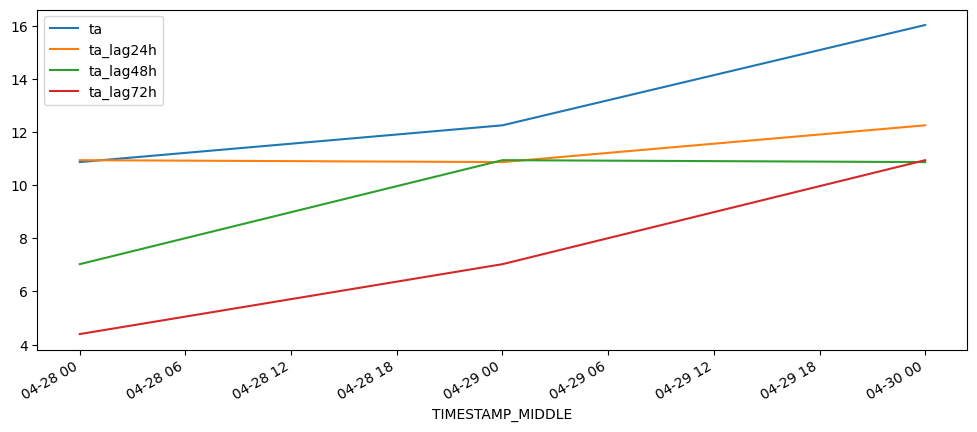

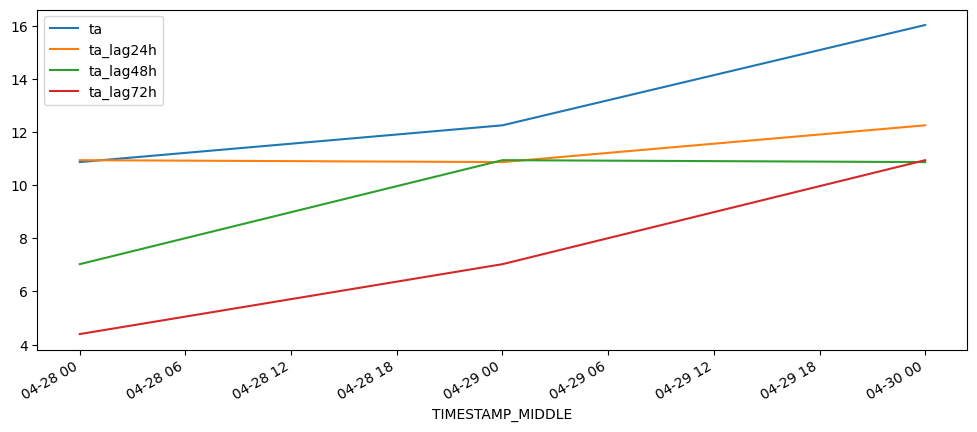

In [207]:
# Define time intervals
intervals = [24, 48, 72] # in hours

# Time resolution of the dataframe
time_res = float(frequency.replace("h", ""))

# Create lagged variants
for df in [df_A, df_B]:
    for v in _list_lag_vars:
        for lag in intervals:
            lag_adjusted = int(lag/time_res)
            if lag_adjusted > 0:
                var_lag = f'{v}_lag{lag}h'
                df[var_lag] = df[v].shift(lag_adjusted)

    # Plot the lag vars for TA
    indat = df[[c for c in df.columns if c.startswith('ta')]]
    indat = indat.loc['2024-04-28':'2024-04-30']
    indat.plot(x_compat=True, figsize=(12, 5));

display(df_A)
display(df_B)

# ROLLING VARIANTS

Variables for which rolling variants will be calculated:

In [208]:
# Define columns of interest
_list_rolling_vars = [c for c in df_A.columns if c.startswith(tuple(_list_lag_vars))]
_list_rolling_vars

['GPP_NT_CUT_50_gfXG_QCF',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG',
 'GPP_NT_CUT_50_gfXG_QCF_lag24h',
 'GPP_NT_CUT_50_gfXG_QCF_lag48h',
 'GPP_NT_CUT_50_gfXG_QCF_lag72h',
 'prec_lag24h',
 'prec_lag48h',
 'prec_lag72h',
 'ta_lag24h',
 'ta_lag48h',
 'ta_lag72h',
 'ts_0.05_gfXG_lag24h',
 'ts_0.05_gfXG_lag48h',
 'ts_0.05_gfXG_lag72h',
 'ts_0.15_gfXG_lag24h',
 'ts_0.15_gfXG_lag48h',
 'ts_0.15_gfXG_lag72h',
 'ts_0.3_gfXG_lag24h',
 'ts_0.3_gfXG_lag48h',
 'ts_0.3_gfXG_lag72h',
 'wfps_0.05_gfXG_lag24h',
 'wfps_0.05_gfXG_lag48h',
 'wfps_0.05_gfXG_lag72h',
 'wfps_0.15_gfXG_lag24h',
 'wfps_0.15_gfXG_lag48h',
 'wfps_0.15_gfXG_lag72h',
 'wfps_0.3_gfXG_lag24h',
 'wfps_0.3_gfXG_lag48h',
 'wfps_0.3_gfXG_lag72h']

Calculate the rolling variants

,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag48h,ts_0.15_gfXG_lag72h,ts_0.3_gfXG_lag24h,ts_0.3_gfXG_lag48h,ts_0.3_gfXG_lag72h,wfps_0.05_gfXG_lag24h,wfps_0.05_gfXG_lag48h,wfps_0.05_gfXG_lag72h,wfps_0.15_gfXG_lag24h,wfps_0.15_gfXG_lag48h,wfps_0.15_gfXG_lag72h,wfps_0.3_gfXG_lag24h,wfps_0.3_gfXG_lag48h,wfps_0.3_gfXG_lag72h,GPP_NT_CUT_50_gfXG_QCF_roll24hsum
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.721848
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,NaN,NaN,7.938342,NaN,NaN,49.426991,NaN,NaN,56.742592,NaN,NaN,46.919334,NaN,NaN,31.705196
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,7.920068,NaN,7.710246,7.938342,NaN,45.816695,49.426991,NaN,55.704364,56.742592,NaN,43.810578,46.919334,NaN,24.046675
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,...,7.388480,7.920068,7.473431,7.710246,7.938342,48.170499,45.816695,49.426991,55.860739,55.704364,56.742592,44.744259,43.810578,46.919334,31.981469
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,...,8.171039,7.388480,7.451685,7.473431,7.710246,45.645659,48.170499,45.816695,55.663368,55.860739,55.704364,43.584212,44.744259,43.810578,25.898211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,...,23.160463,24.090332,21.329807,22.228403,22.443279,27.920504,16.946742,18.440827,41.729594,35.248474,36.871822,41.255257,40.910239,42.456557,50.126077
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,...,21.504869,23.160463,20.393482,21.329807,22.228403,37.491393,27.920504,16.946742,49.009887,41.729594,35.248474,42.875765,41.255257,40.910239,88.270955
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,20.822994,21.504869,20.261765,20.393482,21.329807,35.316930,37.491393,27.920504,47.102637,49.009887,41.729594,42.942952,42.875765,41.255257,117.403265


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag48h,ts_0.15_gfXG_lag72h,ts_0.3_gfXG_lag24h,ts_0.3_gfXG_lag48h,ts_0.3_gfXG_lag72h,wfps_0.05_gfXG_lag24h,wfps_0.05_gfXG_lag48h,wfps_0.05_gfXG_lag72h,wfps_0.15_gfXG_lag24h,wfps_0.15_gfXG_lag48h,wfps_0.15_gfXG_lag72h,wfps_0.3_gfXG_lag24h,wfps_0.3_gfXG_lag48h,wfps_0.3_gfXG_lag72h,GPP_NT_CUT_50_gfXG_QCF_roll24hsum
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.721848
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,NaN,NaN,7.938342,NaN,NaN,49.426991,NaN,NaN,56.742592,NaN,NaN,46.919334,NaN,NaN,31.705196
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,7.920068,NaN,7.710246,7.938342,NaN,45.816695,49.426991,NaN,55.704364,56.742592,NaN,43.810578,46.919334,NaN,24.046675
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,...,7.388480,7.920068,7.473431,7.710246,7.938342,48.170499,45.816695,49.426991,55.860739,55.704364,56.742592,44.744259,43.810578,46.919334,31.981469
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,...,8.171039,7.388480,7.451685,7.473431,7.710246,45.645659,48.170499,45.816695,55.663368,55.860739,55.704364,43.584212,44.744259,43.810578,25.898211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,...,23.160463,24.090332,21.329807,22.228403,22.443279,27.920504,16.946742,18.440827,41.729594,35.248474,36.871822,41.255257,40.910239,42.456557,50.126077
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,...,21.504869,23.160463,20.393482,21.329807,22.228403,37.491393,27.920504,16.946742,49.009887,41.729594,35.248474,42.875765,41.255257,40.910239,88.270955
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,20.822994,21.504869,20.261765,20.393482,21.329807,35.316930,37.491393,27.920504,47.102637,49.009887,41.729594,42.942952,42.875765,41.255257,117.403265


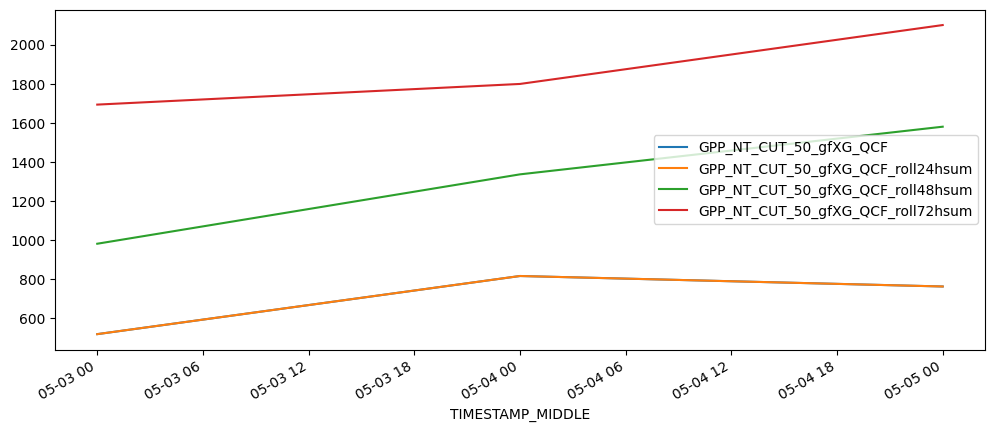

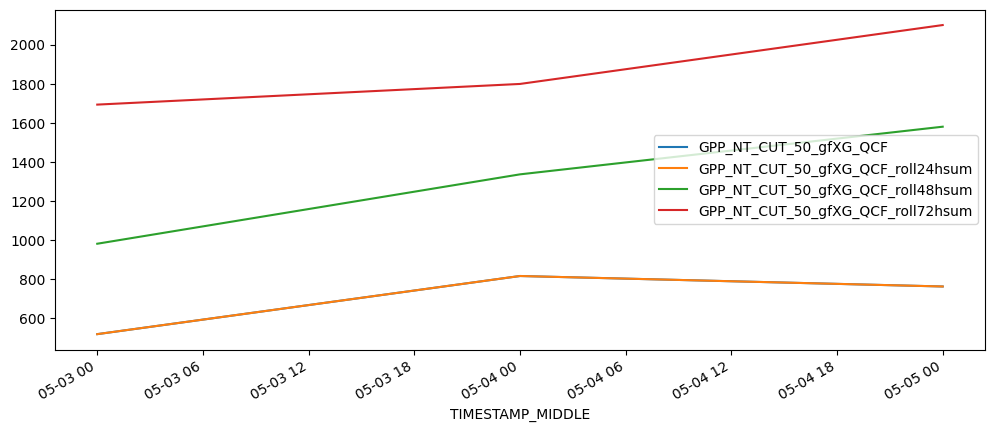

In [209]:
# Define time intervals
#intervals = [24, 48, 72] # in hours

# Time resolution of the dataframe
time_res = float(frequency.replace("h", ""))

# Define the type of aggregations we will apply
aggtypes_default = ['mean']
aggtypes_sum = ['sum'] # for 'prec'


# Create rolling variants
for df in [df_A, df_B]:
    for v in _list_rolling_vars:
        # Determine aggregation type
        aggtypes = aggtypes_sum if v.startswith('prec') or v.startswith('GPP') else aggtypes_default
        for interval in intervals:
            interval_adjusted = int(interval/time_res)
            if interval_adjusted > 0:
                for agg in aggtypes:
                    var_roll = f'{v}_roll{interval}h{agg}'
                    df[var_roll] = df[v].rolling(interval_adjusted, min_periods=1).agg(agg)
                    df = df.copy()

    # Plot the lag vars for GPP
    indat = df[[c for c in df.columns if c.startswith('GPP') and 'lag' not in c]]
    indat = indat.loc['2024-05-03':'2024-05-05']
    indat.plot(x_compat=True, figsize=(12,5));

# Show final dataframes
display(df_A)
display(df_B)

# RATE OF CHANGE

Used for WFPS, TS, and CROP N

In [210]:
# define columns of interest
_list_diff_vars = [col for col in df.columns if ('ts' in col or 'wfps' in col or 'cropN' in col) and ('roll' not in col and 'lag' not in col)]

print(f'We calculate the rate of change for these variables: {_list_diff_vars}')

We calculate the rate of change for these variables: ['ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG', 'cropN']


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.004047,0.007849,NaN
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,...,-0.021746,-0.258561,-0.486658,-2.524840,-0.171036,-3.781332,-0.197371,-0.040996,-1.079224,-1.160047,-0.226365,-3.335122,0.004294,0.008341,0.012143
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,...,0.606866,0.585120,0.348305,0.946756,-1.578084,0.775720,-0.358202,-0.555573,-0.399198,0.186123,-0.973924,-0.040243,0.004542,0.008836,0.012883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.000000
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.000000
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,-0.054096,-0.185812,-1.122138,-3.919772,-6.094235,3.476654,-1.581276,-3.488526,3.791767,-0.243376,-0.176189,1.444318,0.000000,0.000000,0.000000


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.005286,0.010251,NaN
2023-11-20,31.981469,0.000,9.852569,63,8.242761,8.491292,7.451685,45.645659,55.663368,43.584212,34,60,34,0.000000,0.000000,...,-0.021746,-0.258561,-0.486658,-2.524840,-0.171036,-3.781332,-0.197371,-0.040996,-1.079224,-1.160047,-0.226365,-3.335122,0.005610,0.010897,0.015861
2023-11-21,25.898211,3.927,6.930764,71,6.669187,7.946061,8.058551,46.592415,55.305167,43.770335,35,60,35,0.000000,0.000000,...,0.606866,0.585120,0.348305,0.946756,-1.578084,0.775720,-0.358202,-0.555573,-0.399198,0.186123,-0.973924,-0.040243,0.005937,0.011547,0.016833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,50.126077,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.000000,0.000000,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.000000
2024-08-20,88.270955,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.000000,0.000000,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.000000
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,-0.054096,-0.185812,-1.122138,-3.919772,-6.094235,3.476654,-1.581276,-3.488526,3.791767,-0.243376,-0.176189,1.444318,0.000000,0.000000,0.000000


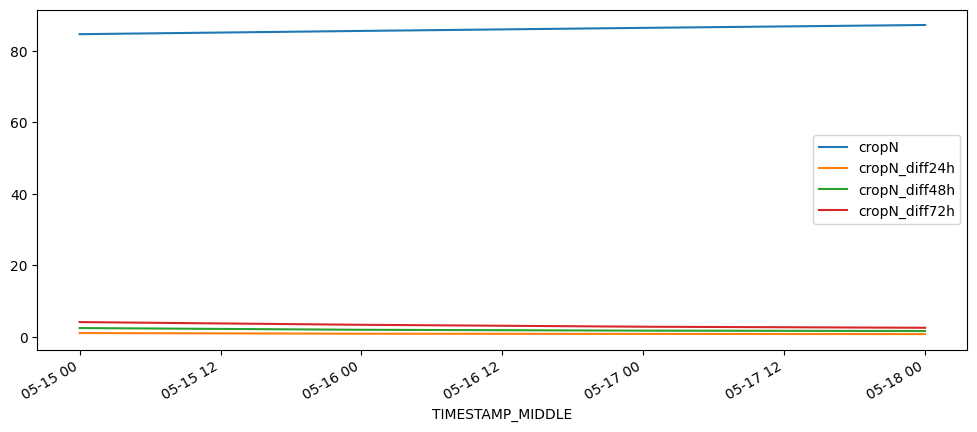

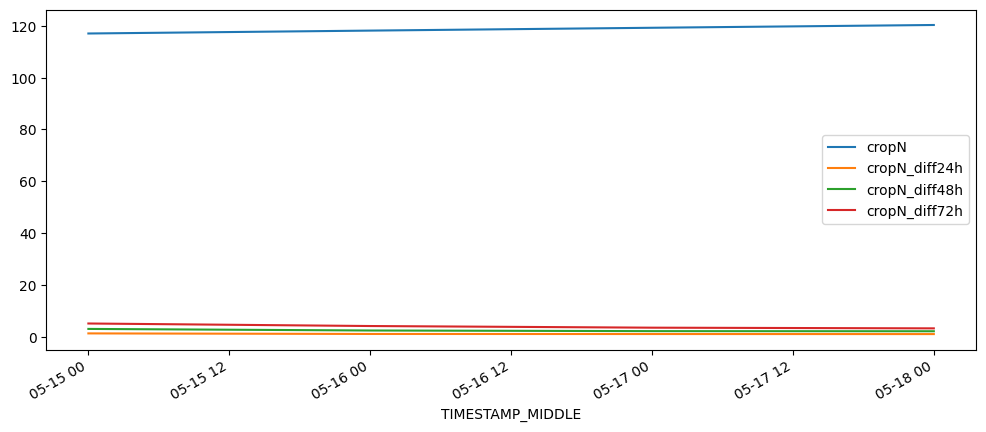

In [211]:
# Define interval of records for the difference calculation
#intervals = [24, 48, 72] # in hours

# Time resolution of the dataframe
time_res = float(frequency.replace("h", ""))

# Create the variants
for df in [df_A, df_B]:
    for v in _list_diff_vars:
        for interval in intervals:
            interval_adjusted = int(interval/time_res)
            if interval_adjusted > 0:
                var_diff = f'{v}_diff{interval}h'
                df[var_diff] = df[v].diff(periods=interval_adjusted)


    # Plot the lag vars for cropN

    indat = df[[c for c in df.columns if c.startswith('cropN') and 'lag' not in c and 'roll' not in c]]
    indat = indat.loc['2024-05-15':'2024-05-18']
    indat.plot(x_compat=True, figsize=(12, 5));

# Show final dataframes
display(df_A)
display(df_B)

# MERGE PARCEL-SPECIFIC DATAFRAMES

In [212]:
# Merge both parcels into a single dataframe
df = pd.concat([df_A, df_B], axis=0).sort_index()
df[['trt', 'FN2O_L3.3_CUT_50_QCF0', 'ta']]

,trt,FN2O_L3.3_CUT_50_QCF0,ta
TIMESTAMP_MIDDLE,,,
2023-11-17,0,0.197910,5.945139
2023-11-17,1,0.005580,5.945139
2023-11-18,1,0.353820,4.470278
2023-11-18,0,0.095548,4.470278
2023-11-19,0,NaN,10.797847
...,...,...,...
2024-08-21,0,NaN,18.000069
2024-08-22,1,1.598566,16.784444
2024-08-22,0,1.268375,16.784444


# EXPORT DATA

## CHECK DATAFRAME

In [213]:
df

,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,21.721848,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,31.705196,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.000000,0.000000,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,24.046675,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.000000,0.000000,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.004047,0.007849,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21,117.403265,0.000,18.000069,131,20.508395,20.826566,20.207669,31.397158,45.521362,42.699576,17,28,60,0.000000,0.000000,...,-0.054096,-0.185812,-1.122138,-3.919772,-6.094235,3.476654,-1.581276,-3.488526,3.791767,-0.243376,-0.176189,1.444318,0.000000,0.000000,0.000000
2024-08-22,36.039470,0.017,16.784444,147,19.817546,19.979660,19.532700,26.909483,44.033058,42.275233,17,29,60,92.927579,93.668081,...,-0.674969,-0.729065,-0.860781,-4.487675,-8.407447,-10.581909,-1.488304,-3.069579,-4.976829,-0.424343,-0.667720,-0.600532,0.000000,0.000000,0.000000
2024-08-22,36.039470,0.017,16.784444,147,19.817546,19.979660,19.532700,26.909483,44.033058,42.275233,17,29,60,92.927579,93.668081,...,-0.674969,-0.729065,-0.860781,-4.487675,-8.407447,-10.581909,-1.488304,-3.069579,-4.976829,-0.424343,-0.667720,-0.600532,0.000000,0.000000,0.000000


Check what columns are contained in the final dataset

In [214]:
print(f'Dataframe contains {len(df.columns)} columns: {sorted(df.columns)}')

Dataframe contains 73 columns: ['FN2O_L3.3_CUT_50_QCF0', 'GPP_NT_CUT_50_gfXG_QCF', 'GPP_NT_CUT_50_gfXG_QCF_lag24h', 'GPP_NT_CUT_50_gfXG_QCF_lag48h', 'GPP_NT_CUT_50_gfXG_QCF_lag72h', 'GPP_NT_CUT_50_gfXG_QCF_roll24hsum', 'cropN', 'cropN_diff24h', 'cropN_diff48h', 'cropN_diff72h', 'n_decay_exponential', 'n_decay_linear', 'n_decay_logistic', 'n_decay_lognormal', 'n_decay_timed', 'prec', 'prec_lag24h', 'prec_lag48h', 'prec_lag72h', 'ta', 'ta_lag24h', 'ta_lag48h', 'ta_lag72h', 'timesince_fert', 'timesince_fert_min', 'timesince_fert_org', 'timesince_harvest', 'timesince_prec', 'timesince_soil_preparation', 'timesince_sowing', 'trt', 'ts_0.05_gfXG', 'ts_0.05_gfXG_diff24h', 'ts_0.05_gfXG_diff48h', 'ts_0.05_gfXG_diff72h', 'ts_0.05_gfXG_lag24h', 'ts_0.05_gfXG_lag48h', 'ts_0.05_gfXG_lag72h', 'ts_0.15_gfXG', 'ts_0.15_gfXG_diff24h', 'ts_0.15_gfXG_diff48h', 'ts_0.15_gfXG_diff72h', 'ts_0.15_gfXG_lag24h', 'ts_0.15_gfXG_lag48h', 'ts_0.15_gfXG_lag72h', 'ts_0.3_gfXG', 'ts_0.3_gfXG_diff24h', 'ts_0.3_gfXG_d

Check the timestamp

In [215]:
# Generate the complete timestamp range
start_date = df.index.min()
end_date = df.index.max()
complete_timestamp = pd.date_range(start=start_date, end=end_date, freq=frequency)

# Compare the complete range with the dataframe's index
missing_timestamps = complete_timestamp.difference(df.index)

# Output the duplicate and missing timestamps
if not missing_timestamps.empty:
    print(f"{len(missing_timestamps)} missing timestamps:")
    print(missing_timestamps)
else:
    print("No missing timestamps found.")

# Check if the timestamp is complete and has no duplicates
if missing_timestamps.empty:
    print("The timestamp index is complete.")
else:
    print("The timestamp index has issues.")

No missing timestamps found.
The timestamp index is complete.


## EXPORT

In [216]:
filename = f"111.1_GapFillingDataset"
save_parquet(data=df, filename=filename)

Saved file 111.1_GapFillingDataset.parquet (0.361 seconds).


'111.1_GapFillingDataset.parquet'

# **End of notebook**

In [217]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-09 11:38:16
